# 카메라 기반 일별 활력도와 향후 3일 이내 돼지 질병 확인 위험의 연관성 평가

**논문/학위논문 초고용 Jupyter Notebook 예시**

이 노트북은 연구질문·가설·판단 기준을 Markdown에 남기고, 데이터 처리·통계·시각화는 Code 셀에서 작은 단계로 실행하는 논문 작성 템플릿입니다.

> **재현 주의:** Notebook이 열린다고 재현되는 것은 아닙니다.  
> 제출·공유 전에는 **Kernel → Restart & Run All**로 처음부터 순서대로 실행하세요.


## 0. Notebook 사용 원칙 (슬라이드 요약)

| 셀 종류 | 역할 |
|---|---|
| **Markdown** | 연구질문·가설·단위·판단 기준·결과 해석을 사람의 언어로 기록 |
| **Code** | 데이터 처리·통계·시각화를 작은 단계로 실행하고 출력을 확인 |
| **주의** | 실행 순서가 꼬이지 않게 Kernel Restart + Run All로 처음부터 재현 |

- 출력만 보고 결론을 쓰지 말고, **판단 기준을 먼저 Markdown에 고정**한 뒤 코드를 실행합니다.
- 분석 중 제외 기준을 바꾸면 Markdown에 변경 시점·이유·영향을 남깁니다.


## 1. 연구 배경

돼지는 질병 초기에 이동량, 섭식, 음수, 자세 변화와 사회적 접촉이 달라질 수 있다. 사람의 순회 관찰만으로 미세한 변화를 연속적으로 확인하기 어렵기 때문에, 영상과 환경센서에서 얻은 행동지표를 이용해 수의사 확인이 필요한 개체를 조기에 선별하는 방법을 검토한다.

본 분석은 활력도 지표의 가능성을 평가하는 **관찰연구 예시**다. 활력도 저하만으로 특정 질병을 진단하거나 인과관계를 주장하지 않는다.

> 본 실습 데이터는 실제 농장과 무관한 **합성데이터**다.


## 2. 연구 질문 · 가설 · 판단 기준

### 연구 질문
1. 질병 확인 1~3일 전 개체의 활력도는 해당 개체의 최근 기준선보다 낮아지는가?
2. 단일 시점 활력도보다 최근 3일 변화량을 포함한 모델의 예측력이 높은가?
3. 환경온도, 습도, 돈방 차이를 고려한 뒤에도 활력도 변화가 조기경보에 기여하는가?

### 가설
- **H1:** `vitality_delta_3d`가 감소할수록 `disease_next_3d=1`의 확률이 증가한다.
- **H2:** 활동량·섭식·누움·기침 변화가 결합된 모델(M2)은 기초모델(M0)보다 **AUPRC**가 높다.
- **H3:** 고온·다습 등 환경성 활력 저하를 보정하면 불필요한 경보가 감소한다.

### 사전 고정 판단 기준 (결과를 보기 전에 기록)
| 항목 | 기준 |
|---|---|
| 측정 단위 | 개체-일 (pig-day) |
| 결과변수 | `disease_next_3d`: 관찰일 다음날부터 3일 이내 임상발현 |
| 주지표 | AUPRC (양성률이 낮아 정확도는 주지표로 쓰지 않음) |
| 보조지표 | AUROC, 민감도, 특이도, PPV, 돼지 100두·일당 경보 수 |
| 모델 비교 | 동일 test 분할에서 M0 < M1 < M2 AUPRC이면 H2 지지 |
| 데이터 분할 | train 0–25일 / validation 26–33일 / test 34–41일 (시간순, 임의 행분할 금지) |
| 임계값 | validation에서 목표 민감도 ≥ 0.80을 만족하는 후보 중 정밀도 최대 |


## 3. 환경 설정

프로젝트 루트를 기준으로 경로를 잡고, 분석에 필요한 라이브러리를 불러온다.


In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid", context="notebook")

# 노트북 위치가 notebooks/ 일 때 프로젝트 루트
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
elif not (ROOT / "data" / "clean" / "practice_dataset.csv").exists():
    # Cursor 등에서 프로젝트 루트로 열린 경우
    candidate = Path(".").resolve()
    ROOT = candidate if (candidate / "data").exists() else Path.cwd()

RAW = ROOT / "data" / "raw"
CLEAN = ROOT / "data" / "clean"
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

print("ROOT:", ROOT)
print("존재 확인:", (CLEAN / "practice_dataset.csv").exists())


ROOT: /Users/int/Projects/pig-vitality-disease-prediction-practice
존재 확인: True


## 4. 자료 불러오기

원자료 3종과 정제된 입문용 자료를 각각 읽어 행·열 수를 확인한다.


In [2]:
observations = pd.read_csv(
    RAW / "pig_daily_observations.csv",
    parse_dates=["observation_date"],
)
metadata = pd.read_csv(RAW / "pig_metadata.csv", parse_dates=["birth_date", "arrival_date"])
events = pd.read_csv(
    RAW / "disease_events.csv",
    parse_dates=["clinical_onset_date", "confirmation_date", "treatment_date", "recovery_date"],
)
practice = pd.read_csv(
    CLEAN / "practice_dataset.csv",
    parse_dates=["observation_date"],
)

summary = pd.DataFrame({
    "file": ["pig_daily_observations", "pig_metadata", "disease_events", "practice_dataset"],
    "n_rows": [len(observations), len(metadata), len(events), len(practice)],
    "n_cols": [observations.shape[1], metadata.shape[1], events.shape[1], practice.shape[1]],
    "n_pigs": [
        observations["pig_id"].nunique(),
        metadata["pig_id"].nunique(),
        events["pig_id"].nunique(),
        practice["pig_id"].nunique(),
    ],
})
summary


,file,n_rows,n_cols,n_pigs
0,pig_daily_observations,5045,21,120
1,pig_metadata,120,7,120
2,disease_events,36,9,36
3,practice_dataset,4269,28,120


### 해석 메모 (작성 예시)
- 원 관찰자료는 약 5,000행 규모이며, 메타데이터는 개체당 1행(120두)이다.
- `practice_dataset`은 QC·라벨·과거 변화량이 반영된 **분석 대상 자료**로 사용한다.
- 이후 모든 모델 비교는 `practice`만 사용하고, 원자료는 품질 보고용으로만 쓴다.


## 5. 데이터 품질 점검

### 사전 제외·품질 기준 (실험계획서 §8)
1. `(pig_id, observation_date)` 완전 중복 제거  
2. `valid=False` 제외 후 사유 집계  
3. 카메라 커버리지 70% 미만 제외  
4. 이동거리 음수, 누움 비율 0–1 밖, 커버리지 0–100 밖 제외  
5. 핵심 영상변수 결측 행 제외  

결측·제외 기준은 결과를 본 뒤 유리하게 변경하지 않는다.


In [3]:
print("=== 중복 pig-day ===")
n_dup = observations.duplicated(["pig_id", "observation_date"]).sum()
print(f"중복 행 수: {n_dup}")

print("\n=== valid / qc_note ===")
print(observations["valid"].value_counts(dropna=False))
print(observations["qc_note"].fillna("(없음)").value_counts().head(10))

print("\n=== 결측 Top 10 ===")
print(observations.isna().sum().sort_values(ascending=False).head(10))

print("\n=== 범위 오류 후보 ===")
range_issues = {
    "distance_m < 0": (observations["distance_m"] < 0).sum(),
    "lying_ratio 범위밖": ((observations["lying_ratio"] < 0) | (observations["lying_ratio"] > 1)).sum(),
    "coverage 범위밖": (
        (observations["camera_coverage_pct"] < 0) | (observations["camera_coverage_pct"] > 100)
    ).sum(),
    "coverage < 70": (observations["camera_coverage_pct"] < 70).sum(),
}
pd.Series(range_issues)


=== 중복 pig-day ===
중복 행 수: 5

=== valid / qc_note ===
valid
True     5042
False       3
Name: count, dtype: int64
qc_note
(없음)                        5042
negative_distance              1
coverage_out_of_range          1
lying_ratio_out_of_range       1
Name: count, dtype: int64

=== 결측 Top 10 ===
qc_note             5042
activity_minutes      71
distance_m            64
lying_ratio           62
feeding_minutes       61
weight_kg              0
age_days               0
mean_speed_m_s         0
pen_id                 0
feeding_visits         0
dtype: int64

=== 범위 오류 후보 ===


distance_m < 0     1
lying_ratio 범위밖    1
coverage 범위밖       1
coverage < 70      0
dtype: int64

### 품질 보고 (논문 Methods에 넣을 4문장 초고)

1. 원 관찰자료에서 `(pig_id, observation_date)` 중복과 `valid=False`, 커버리지·범위 오류를 점검했다.  
2. 분석용 `practice_dataset`은 위 기준을 반영한 정제 결과이며, 원자료와 별도 보존한다.  
3. 메타데이터는 `pig_id` 기준 many-to-one 병합을 전제로 하며, 질병 이벤트는 임상발현일로 라벨을 역산한다.  
4. 처치일·회복일·확인일 자체는 예측변수로 사용하지 않아 라벨 누수를 방지한다.


## 6. 분석 대상과 라벨 정의

- **예측시점:** 매일 관찰 종료 시점  
- **예측범위:** 다음날부터 3일 이내  
- **라벨:** `disease_next_3d=1`이면 해당 기간에 임상발현일이 존재  
- **분할:** `split` 열의 train / validation / test (시간순)


In [4]:
label_by_split = (
    practice.groupby("split", sort=False)["disease_next_3d"]
    .agg(n="size", positives="sum", prevalence="mean")
    .reindex(["train", "validation", "test"])
)
label_by_split["prevalence_pct"] = (100 * label_by_split["prevalence"]).round(2)
label_by_split


,n,positives,prevalence,prevalence_pct
split,,,,
train,2860,52,0.018182,1.82
validation,743,28,0.037685,3.77
test,666,25,0.037538,3.75


In [5]:
print("질병 이벤트 증후군·중증도")
display(events.groupby(["syndrome", "severity"]).size().unstack(fill_value=0))

print("\n양성 vs 음성 개체-일의 활력도·변화량")
practice.groupby("disease_next_3d")[
    ["vitality_score", "vitality_delta_3d", "activity_minutes", "cough_events"]
].agg(["mean", "median", "std"]).round(2)


질병 이벤트 증후군·중증도


severity,mild,moderate,severe
syndrome,,,
enteric,3,3,0
lameness,4,3,1
respiratory,13,7,2



양성 vs 음성 개체-일의 활력도·변화량


vitality_score               vitality_delta_3d               \
                          mean median    std              mean median   std   
disease_next_3d                                                               
0                        55.02   54.2  18.82             -0.12   -0.1  5.95   
1                        36.79   37.2  20.56             -9.57   -9.6  5.95   

                activity_minutes               cough_events               
                            mean median    std         mean median   std  
disease_next_3d                                                           
0                         106.43  105.4  29.58         0.46    0.0  0.70  
1                          86.52   87.2  32.90         2.16    2.0  1.65

### 해석
- 양성률이 낮으므로 **정확도**보다 **AUPRC**와 경보량(alerts/100 pig-days)을 함께 본다.
- 양성 군에서 `vitality_delta_3d` 평균이 더 낮으면 H1을 기술적으로 지지하는 단서가 된다 (인과 아님).


## 7. 기술통계 · 탐색적 시각화

돈방·라벨별 분포와 활력도–온도 관계를 확인해, 환경 교란 가능성을 논문 Discussion에 남길 근거를 만든다.


/var/folders/2w/czt1dksj7n1fkx5s68r2938w0000gn/T/ipykernel_81574/2512128791.py:27: UserWarning: Glyph 54788 (\N{HANGUL SYLLABLE HYEON}) missing from font(s) Arial.
  fig.savefig(RESULTS / "thesis_eda_vitality.png", dpi=160)
/var/folders/2w/czt1dksj7n1fkx5s68r2938w0000gn/T/ipykernel_81574/2512128791.py:27: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) Arial.
  fig.savefig(RESULTS / "thesis_eda_vitality.png", dpi=160)
/var/folders/2w/czt1dksj7n1fkx5s68r2938w0000gn/T/ipykernel_81574/2512128791.py:27: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) Arial.
  fig.savefig(RESULTS / "thesis_eda_vitality.png", dpi=160)
/var/folders/2w/czt1dksj7n1fkx5s68r2938w0000gn/T/ipykernel_81574/2512128791.py:27: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) Arial.
  fig.savefig(RESULTS / "thesis_eda_vitality.png", dpi=160)
/var/folders/2w/czt1dksj7n1fkx5s68r2938w0000gn/T/ipykernel_81574/2512128791.py:27: UserWarning: Glyph 51068 (\N

/Users/int/Projects/pig-vitality-disease-prediction-practice/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 54788 (\N{HANGUL SYLLABLE HYEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/int/Projects/pig-vitality-disease-prediction-practice/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/int/Projects/pig-vitality-disease-prediction-practice/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/int/Projects/pig-vitality-disease-prediction-practice/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Us

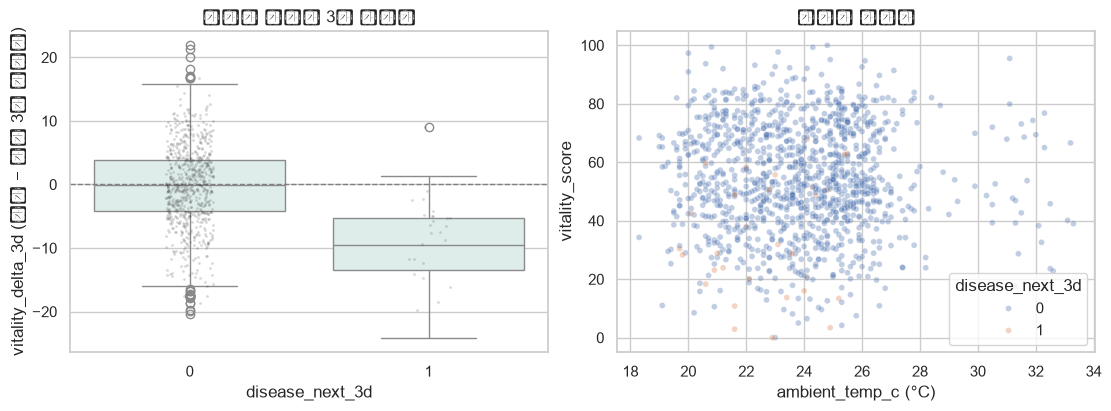

저장: /Users/int/Projects/pig-vitality-disease-prediction-practice/results/thesis_eda_vitality.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")

sns.boxplot(
    data=practice, x="disease_next_3d", y="vitality_delta_3d",
    ax=axes[0], color="#DCEFEB",
)
sns.stripplot(
    data=practice.sample(n=min(800, len(practice)), random_state=42),
    x="disease_next_3d", y="vitality_delta_3d",
    ax=axes[0], color="0.25", alpha=0.2, size=2,
)
axes[0].axhline(0, color="0.5", ls="--", lw=1)
axes[0].set(
    xlabel="disease_next_3d",
    ylabel="vitality_delta_3d (현재 − 이전 3일 중앙값)",
    title="라벨별 활력도 3일 변화량",
)

sns.scatterplot(
    data=practice.sample(n=min(1200, len(practice)), random_state=0),
    x="ambient_temp_c", y="vitality_score",
    hue="disease_next_3d", alpha=0.35, s=18, ax=axes[1],
)
axes[1].set(xlabel="ambient_temp_c (°C)", ylabel="vitality_score", title="온도와 활력도")
axes[1].legend(title="disease_next_3d", loc="best")

fig.savefig(RESULTS / "thesis_eda_vitality.png", dpi=160)
plt.show()
print("저장:", RESULTS / "thesis_eda_vitality.png")


In [7]:
pen_summary = (
    practice.groupby("pen_id")
    .agg(
        n_rows=("pig_id", "size"),
        n_pigs=("pig_id", "nunique"),
        mean_vitality=("vitality_score", "mean"),
        mean_delta=("vitality_delta_3d", "mean"),
        positive_rate=("disease_next_3d", "mean"),
        mean_temp=("ambient_temp_c", "mean"),
    )
    .round(3)
)
pen_summary


,n_rows,n_pigs,mean_vitality,mean_delta,positive_rate,mean_temp
pen_id,,,,,,
PEN01,548,15,57.746,-0.366,0.022,24.084
PEN02,531,15,52.513,-0.379,0.023,23.140
PEN03,533,15,55.562,-0.513,0.026,23.763
PEN04,574,15,55.394,-0.238,0.016,25.014
PEN05,544,15,51.507,-0.183,0.017,23.274
PEN06,529,15,56.158,-0.414,0.034,23.564
PEN07,452,15,52.334,-0.574,0.049,23.358
PEN08,558,15,54.882,-0.311,0.016,24.780


## 8. 비교 모델 정의

실험계획서의 M0–M2를 그대로 따른다. 수업/논문 초고에서는 **해석 가능한 로지스틱 회귀**를 기본으로 한다.

| 모델 | 포함 변수 |
|---|---|
| **M0** 기초 | 나이, 체중, 온도, 습도, 돈방 |
| **M1** 현재 활력 | M0 + 당일 행동·활력도·카메라 커버리지 |
| **M2** 변화 | M1 + `vitality_delta_3d`, `activity_delta_pct_3d`, `cough_events_prior_3d` |


In [8]:
TARGET = "disease_next_3d"

FEATURE_SETS = {
    "M0_baseline": [
        "age_days", "weight_kg", "ambient_temp_c", "humidity_pct", "pen_id",
    ],
    "M1_current_vitality": [
        "age_days", "weight_kg", "ambient_temp_c", "humidity_pct", "pen_id",
        "activity_minutes", "distance_m", "lying_ratio", "feeding_visits",
        "feeding_minutes", "drinking_visits", "social_contacts",
        "posture_changes", "cough_events", "vitality_score",
        "camera_coverage_pct",
    ],
    "M2_change": [
        "age_days", "weight_kg", "ambient_temp_c", "humidity_pct", "pen_id",
        "activity_minutes", "distance_m", "lying_ratio", "feeding_visits",
        "feeding_minutes", "drinking_visits", "social_contacts",
        "posture_changes", "cough_events", "vitality_score",
        "camera_coverage_pct",
        "vitality_delta_3d", "activity_delta_pct_3d", "cough_events_prior_3d",
    ],
}


def build_model(features):
    categorical = [c for c in features if c in {"pen_id", "sex", "breed"}]
    numeric = [c for c in features if c not in categorical]
    prep = ColumnTransformer([
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ])
    return Pipeline([
        ("prep", prep),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced")),
    ])


def choose_threshold(y_true, probabilities, min_sensitivity=0.80):
    """validation에서 민감도 ≥ 0.80을 만족하는 임계값 중 정밀도 최대."""
    best = None
    for threshold in np.unique(probabilities):
        pred = probabilities >= threshold
        tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
        sensitivity = tp / (tp + fn) if tp + fn else 0.0
        precision = tp / (tp + fp) if tp + fp else 0.0
        if sensitivity >= min_sensitivity:
            item = (precision, -threshold, float(threshold))
            if best is None or item > best:
                best = item
    return float(best[2] if best else 0.5)


def compute_metrics(y_true, probabilities, threshold):
    pred = probabilities >= threshold
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "n": int(len(y_true)),
        "positives": int(np.sum(y_true)),
        "auprc": float(average_precision_score(y_true, probabilities)),
        "auroc": float(roc_auc_score(y_true, probabilities)),
        "threshold": float(threshold),
        "sensitivity": float(tp / (tp + fn) if tp + fn else 0),
        "specificity": float(tn / (tn + fp) if tn + fp else 0),
        "ppv": float(tp / (tp + fp) if tp + fp else 0),
        "alerts_per_100_pig_days": float(100 * (tp + fp) / len(y_true)),
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
    }

print("모델별 특성 수:", {k: len(v) for k, v in FEATURE_SETS.items()})


모델별 특성 수: {'M0_baseline': 5, 'M1_current_vitality': 16, 'M2_change': 19}


## 9. 학습 · 검증 · 최종 평가

1. train으로 적합  
2. validation에서 임계값 선택 (민감도 ≥ 0.80)  
3. **test는 최종 1회만** 평가  

동일 개체의 인접 날짜를 무작위로 섞어 행 분할하지 않는다.


In [9]:
# 변화량 결측(연구 초반 등)은 모델 비교를 위해 행 단위로 제외
needed = sorted(set().union(*FEATURE_SETS.values()))
model_df = practice.dropna(subset=needed + [TARGET]).copy()

train = model_df.loc[model_df["split"].eq("train")]
validation = model_df.loc[model_df["split"].eq("validation")]
test = model_df.loc[model_df["split"].eq("test")]

print("분석 행 수:", len(model_df))
print("train / val / test:", len(train), len(validation), len(test))
print("test 양성률:", round(test[TARGET].mean(), 4))

all_results = {}
prediction_frame = test[["observation_date", "pig_id", "pen_id", TARGET]].copy()

for name, features in FEATURE_SETS.items():
    model = build_model(features)
    model.fit(train[features], train[TARGET])
    val_prob = model.predict_proba(validation[features])[:, 1]
    threshold = choose_threshold(validation[TARGET].to_numpy(), val_prob)
    test_prob = model.predict_proba(test[features])[:, 1]
    all_results[name] = compute_metrics(test[TARGET].to_numpy(), test_prob, threshold)
    prediction_frame[f"prob_{name}"] = test_prob

metric_table = pd.DataFrame(all_results).T.reset_index(names="model")
cols = ["model", "auprc", "auroc", "sensitivity", "specificity", "ppv", "alerts_per_100_pig_days"]
metric_table[cols].round(3)


분석 행 수: 4029
train / val / test: 2620 743 666
test 양성률: 0.0375


,model,auprc,auroc,sensitivity,specificity,ppv,alerts_per_100_pig_days
0,M0_baseline,0.051,0.574,0.00,0.989,0.000,1.051
1,M1_current_vitality,0.488,0.901,0.40,0.991,0.625,2.402
2,M2_change,0.759,0.982,0.68,0.992,0.773,3.303


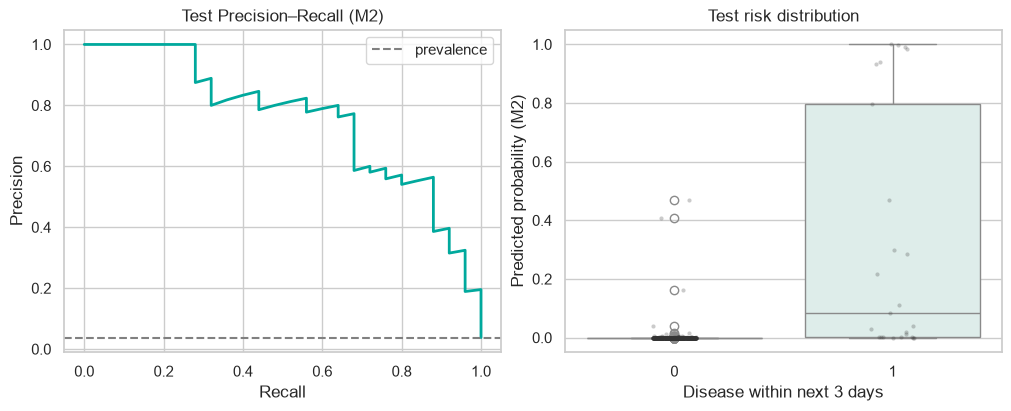

저장: /Users/int/Projects/pig-vitality-disease-prediction-practice/results/thesis_model_evaluation.png


In [10]:
# Results 저장 (논문 부록/재현용)
(RESULTS / "thesis_metrics.json").write_text(
    json.dumps(all_results, ensure_ascii=False, indent=2), encoding="utf-8"
)
metric_table.to_csv(RESULTS / "thesis_model_comparison.csv", index=False)
prediction_frame.to_csv(RESULTS / "thesis_test_predictions.csv", index=False)

best_prob = prediction_frame["prob_M2_change"]
precision, recall, _ = precision_recall_curve(test[TARGET], best_prob)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
axes[0].plot(recall, precision, color="#00A99D", linewidth=2)
axes[0].axhline(test[TARGET].mean(), color="0.5", linestyle="--", label="prevalence")
axes[0].set(xlabel="Recall", ylabel="Precision", title="Test Precision–Recall (M2)")
axes[0].legend()

sns.boxplot(
    data=prediction_frame, x=TARGET, y="prob_M2_change",
    ax=axes[1], color="#DCEFEB",
)
sns.stripplot(
    data=prediction_frame, x=TARGET, y="prob_M2_change",
    ax=axes[1], color="0.2", alpha=0.25, size=3,
)
axes[1].set(
    xlabel="Disease within next 3 days",
    ylabel="Predicted probability (M2)",
    title="Test risk distribution",
)

fig.savefig(RESULTS / "thesis_model_evaluation.png", dpi=180)
plt.show()
print("저장:", RESULTS / "thesis_model_evaluation.png")


## 10. 결과 해석 (Results / Discussion 초고)

아래 문장은 **실행 결과 표를 확인한 뒤** 숫자를 채워 논문에 옮긴다.

### 결과 (초안 문장)
1. 동일 test 자료에서 M0 → M1 → M2로 갈수록 AUPRC가 증가하면, 당일 활력도에 더해 **최근 3일 변화량**이 예측력에 기여한다고 해석할 수 있다 (H2).  
2. 양성 군에서 `vitality_delta_3d`가 더 낮게 관측되면 H1과 방향이 일치한다. 다만 관찰연구이므로 인과를 주장하지 않는다.  
3. 민감도를 validation에서 고정한 뒤의 test 경보량(`alerts_per_100_pig_days`)은 현장 업무 부담을 논할 때 함께 보고한다.  
4. 모델 출력은 **진단이 아니라** 수의사 확인 우선순위를 정하는 보조정보다.

### 한계
- 합성데이터이며 외부 농장 검증이 없다.  
- 수의사 확인 시점이 실제 임상발현보다 늦을 수 있다.  
- 고온·다습·카메라 사각지대가 활력도 저하처럼 보일 수 있다.  
- 돈방·사양관리 차이가 지름길(shortcut)이 될 수 있어 돈방별 오류를 별도 검토해야 한다.


In [11]:
# 논문 Results에 붙일 핵심 숫자만 요약
focus = metric_table.set_index("model")[["auprc", "auroc", "sensitivity", "ppv", "alerts_per_100_pig_days"]]
print("=== Test 성능 요약 ===")
display(focus.round(3))

print("\nH2 체크: M2 AUPRC > M0 AUPRC ?",
      all_results["M2_change"]["auprc"] > all_results["M0_baseline"]["auprc"])
print("H2 체크: M2 AUPRC > M1 AUPRC ?",
      all_results["M2_change"]["auprc"] > all_results["M1_current_vitality"]["auprc"])


=== Test 성능 요약 ===


,auprc,auroc,sensitivity,ppv,alerts_per_100_pig_days
model,,,,,
M0_baseline,0.051,0.574,0.00,0.000,1.051
M1_current_vitality,0.488,0.901,0.40,0.625,2.402
M2_change,0.759,0.982,0.68,0.773,3.303



H2 체크: M2 AUPRC > M0 AUPRC ? True
H2 체크: M2 AUPRC > M1 AUPRC ? True


## 11. 결론 4문장 (제출물 양식)

1. **데이터:** 8개 돈방·120두·42일 합성 관찰코호트의 개체-일 자료를 시간순으로 분할해 분석했다.  
2. **결과:** 기초모델 대비 활력도·3일 변화량을 포함한 모델의 test AUPRC가 더 높았다(표 참고).  
3. **활용:** 출력은 조기경보 위험도로, 순회 관찰 우선순위 설정에만 보조적으로 사용한다.  
4. **한계:** 합성·단일 시설 설정이므로 외부 검증·라벨 지연·환경 교란을 해소하기 전에는 현장에 직접 적용하지 않는다.


## 12. 재현 체크리스트

- [ ] Kernel **Restart & Run All**로 처음부터 오류 없이 끝까지 실행됨  
- [ ] 경로가 `ROOT` 기준이라 다른 작업 디렉터리에서도 동작함  
- [ ] test는 임계값 선택에 사용하지 않음 (validation만 사용)  
- [ ] 치료일·회복일을 feature로 넣지 않음  
- [ ] 그림·표 파일명과 Markdown 해석 문장이 일치함  
- [ ] AI 사용 시 도구·목적·검증 내역을 `docs/04_AI_research_ethics_checklist.md`에 기록함

---
*본 노트북은 `docs/01_experiment_plan.md`와 `src/solution_reference.py`를 논문 작성 흐름에 맞게 재구성한 예시입니다.*
